# 03 — Specificity, confound, and capability controls

All controls use the 155 frozen-clean-eligible raw $W_UJ$ cases from notebook 02. Final concept-token suppression is asserted to be exactly zero because every concept token ID is disjoint from the target and foil token IDs used by the behavior metric. It is therefore a structural instrumentation/direct-logit-steering check, not additional causal evidence. Additional controls are seeded matched-unit random ablations, a primary absent-coordinate null, off-target language/task capability, the upstream language-label narration case, and an identity-Jacobian/logit-lens baseline joined to the same measured core causal outcome. The absent null swaps the first two rank-qualified absent coordinates while leaving the task concept untouched. The earlier task-concept-to-absent intervention is retained for all 155 items under the honest label *non-null specificity stress test*, because it removes and replaces the active task-concept coordinate. No control item is selected using its intervention effect. A pre-intervention rank-only feasibility audit found the initial never-top-1000 absence rule infeasible for 2/155 prompts (best ranks 986 and 750); before observing any swap effect, the single-candidate rule was frozen at never-top-500, which all 155 prompts satisfy. At that unchanged threshold, 153/155 prompts have a second eligible absent candidate for the pair null; the two pair-infeasible items are excluded from that null before its behavior outcomes are evaluated and retained in the feasibility audit.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
metrics = json.loads(metrics_path.read_text())
core = metrics['twohop']['qwen2.5-7b-instruct']
primary_rows = [row for row in core['rows'] if row['direction_method'] == 'jlens_raw_wu_j' and row['measurement_status'] == 'OK']
print('Primary control population:', len(primary_rows))

Primary control population: 155


In [2]:
from src.jlens_iface import jlens_direction_bank, load_published_lens
from src.model_utils import load_model, release_model, set_seed

set_seed(1729)
bundle = load_model('Qwen/Qwen2.5-7B-Instruct')
lens = load_published_lens(bundle.model_id)
layers = core['metadata']['workspace_layers']
items = []
flat_core = []
for row in primary_rows:
    item = {
        'name': row['name'], 'prompt': row['prompt'], 'category': row['category'],
        'intermediate': row['intermediate'], 'swap_to': row['swap_to'],
        'concept_token_id': row['token_ids']['concept'],
        'foil_concept_token_id': row['token_ids']['foil_concept'],
        'target_token_id': row['token_ids']['target'], 'foil_token_id': row['token_ids']['foil'],
    }
    items.append(item)
    flat_core.append({
        'name': row['name'],
        'suppression_delta': row['output_suppression']['concept']['delta'],
        'actual_delta': row['ablation']['delta'],
        'predicted_delta': row['aggregate']['first_order_predicted_delta'],
        'write_strength': row['aggregate']['write_abs_mean'],
    })
token_bank = jlens_direction_bank(lens, bundle.lens_model, [item['concept_token_id'] for item in items], layers, fold_rms_gain=False)
direction_banks = {item['name']: token_bank[item['concept_token_id']] for item in items}
print('Prepared raw W_U J controls:', len(direction_banks), 'items ×', len(layers), 'layers')

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Prepared raw W_U J controls: 155 items × 15 layers


In [3]:
from src.controls_phase import run_controls_phase

controls = run_controls_phase(
    bundle, lens, items, direction_banks, flat_core, layers,
    n_random_draws=16,
    absent_min_rank=500,
    control_n_bootstrap=5000,
    capability_tasks_per_intervention=4,
    seed=1729,
    output_path=ROOT / 'data/raw/03_controls_qwen7b.json',
    figures_dir=ROOT / 'results/figures',
)
release_model(bundle)

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## Curated metrics versus raw audit trail

The complete seeded null draws, both absent-candidate selections, token ranks, pair-feasibility exclusions, per-position arrays, and cross-task records are saved under `data/raw/` for reproduction. `results/metrics.json` retains every available per-concept control effect, the pre-behavior pair-feasibility audit, both honestly labelled absent interventions, and bootstrap aggregate summaries while omitting repetitive hashes and full rank matrices so the required versioned metrics file remains below the repository's 50 MB limit.

In [4]:
from src.metrics import save_json

curated = {key: controls[key] for key in ('seed', 'effect_sign', 'n_items', 'workspace_layers', 'core_output_suppression_assertion', 'causal_predictor_comparison', 'direction_convention_for_absent_and_language_labels', 'figures', 'limitations')}
curated['random_direction_null'] = {
    'seed': controls['random_direction_null']['seed'],
    'n_draws_per_item': controls['random_direction_null']['n_draws_per_item'],
    'direction_rule': controls['random_direction_null']['direction_rule'],
    'aggregate': controls['random_direction_null']['aggregate'],
    'rows': [{key: row[key] for key in ('name', 'n_draws', 'observed_concept_delta', 'null_summary', 'empirical_comparison')} for row in controls['random_direction_null']['rows']],
}
curated['absent_coordinate_null'] = {
    **{key: controls['absent_coordinate_null'][key] for key in ('control_role', 'intervention', 'expected_effect', 'selection_timing', 'min_rank_threshold', 'candidate_token_order', 'n_bootstrap', 'confidence', 'rank_feasibility', 'aggregate')},
    'rows': [{key: row[key] for key in ('name', 'selected_absent_token_ids', 'selected_absent_surfaces', 'pair_selection', 'clean_metric', 'edited_metric', 'delta')} for row in controls['absent_coordinate_null']['rows']],
    'rank_infeasible_rows': [{key: row[key] for key in ('name', 'status', 'selected_first_absent_token_id', 'selected_first_absent_surface', 'first_selection', 'pair_selection_audit', 'selection_exclusions')} for row in controls['absent_coordinate_null']['rank_infeasible_rows']],
}
curated['concept_to_absent_stress_test'] = {
    **{key: controls['concept_to_absent_stress_test'][key] for key in ('control_role', 'intervention', 'expected_effect', 'selection_timing', 'min_rank_threshold', 'candidate_token_order', 'n_bootstrap', 'confidence', 'aggregate')},
    'rows': [{key: row[key] for key in ('name', 'selected_absent_token_id', 'selected_absent_surface', 'selection', 'clean_metric', 'edited_metric', 'delta')} for row in controls['concept_to_absent_stress_test']['rows']],
}
curated['capability'] = controls['capability']
curated['known_narration'] = controls['known_narration']
curated['logit_lens_identity_jacobian'] = {
    'direction_definition': controls['logit_lens_identity_jacobian']['direction_definition'],
    'predictor': controls['logit_lens_identity_jacobian']['predictor'],
    'rows': [{key: row[key] for key in ('name', 'write_sum', 'write_strength', 'predicted_delta', 'actual_delta', 'clean_metric', 'ablated_metric')} for row in controls['logit_lens_identity_jacobian']['rows']],
}
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('controls', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated controls merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated controls merged; metrics size MiB: 40.735405921936035


In [5]:
import numpy as np
import pandas as pd

supp = controls['core_output_suppression_assertion']['comparison']
supp_structure = controls['core_output_suppression_assertion']['structural_zero_assertion']
assert supp_structure['all_token_ids_disjoint'] is True
assert supp_structure['all_deltas_exact_zero'] is True
assert all(row['concept_disjoint_from_target_and_foil'] and row['output_suppression_delta'] == 0.0 and row['exact_zero'] for row in supp_structure['rows'])
random_rows = controls['random_direction_null']['rows']
random_aggregate = controls['random_direction_null']['aggregate']
absent_null = controls['absent_coordinate_null']
absent_stress = controls['concept_to_absent_stress_test']
cap = controls['capability']
narr = controls['known_narration']
display(pd.DataFrame([
    {'control': 'internal ablation median |delta|', 'value': supp['median_abs_internal_effect']},
    {'control': 'structural final concept-logit clamp median |delta|', 'value': supp['median_abs_output_effect']},
    {'control': 'random-null median SD across concepts', 'value': float(np.median([row['null_summary']['std'] for row in random_rows]))},
    {'control': 'random-null mean |delta|', 'value': random_aggregate['mean_abs_random_delta']['estimate']},
    {'control': 'observed minus random mean |delta|', 'value': random_aggregate['paired_mean_abs_observed_minus_random']['estimate']},
    {'control': 'absent↔absent rank-feasible items', 'value': absent_null['rank_feasibility']['n_items_included']},
    {'control': 'absent↔absent null mean |delta|', 'value': absent_null['aggregate']['mean_abs_delta']['estimate']},
    {'control': 'concept→absent stress mean |delta| (not a null)', 'value': absent_stress['aggregate']['mean_abs_delta']['estimate']},
    {'control': 'fixed-text mean delta NLL', 'value': cap['general_language']['mean_delta_nll']},
    {'control': 'off-target clean accuracy', 'value': cap['twohop']['clean_accuracy']},
    {'control': 'off-target edited accuracy', 'value': cap['twohop']['edited_accuracy']},
]))
print('Absent-coordinate null rank feasibility:', absent_null['rank_feasibility'])
print('Absent-coordinate null mean delta CI:', absent_null['aggregate']['mean_delta'])
print('Absent-coordinate null mean |delta| CI:', absent_null['aggregate']['mean_abs_delta'])
print('Concept-to-absent stress test is retained but is NOT a null.')
print('Final concept-logit clamp:', supp_structure['classification'])
print('Disjoint IDs / exact-zero deltas:', supp_structure['all_token_ids_disjoint'], supp_structure['all_deltas_exact_zero'])
print('Known narration gate:', narr['reproduction_gate'])
display(pd.DataFrame(controls['causal_predictor_comparison']['shared_core_causal_target']).T)

,control,value
0,internal ablation median |delta|,3.125000
1,structural final concept-logit clamp median |d...,0.000000
2,random-null median SD across concepts,0.491381
3,random-null mean |delta|,0.428274
4,observed minus random mean |delta|,2.961179
5,absent↔absent rank-feasible items,153.000000
6,absent↔absent null mean |delta|,0.568857
7,concept→absent stress mean |delta| (not a null),11.988962
8,fixed-text mean delta NLL,0.066081
9,off-target clean accuracy,0.967742


Absent-coordinate null rank feasibility: {'criterion': 'at least two preregistered nonexcluded candidates meet the frozen rank threshold before behavior evaluation', 'n_items_total': 155, 'n_items_included': 153, 'n_items_excluded': 2, 'excluded_item_names': ['instr-body-trumpet', 'person-firstname-mozart']}
Absent-coordinate null mean delta CI: {'n': 153, 'estimate': -0.055376838235294115, 'ci_level': 0.95, 'ci_low': -0.1828635620915032, 'ci_high': 0.06215150122549007, 'n_bootstrap': 5000, 'seed': 61729}
Absent-coordinate null mean |delta| CI: {'n': 153, 'estimate': 0.5688572303921569, 'ci_level': 0.95, 'ci_low': 0.4872593698937909, 'ci_high': 0.6564561631944444, 'n_bootstrap': 5000, 'seed': 61730}
Concept-to-absent stress test is retained but is NOT a null.
Final concept-logit clamp: structural-zero instrumentation/direct-logit-steering check; not additional causal evidence
Disjoint IDs / exact-zero deltas: True True
Known narration gate: {'status': 'FAIL', 'n_passages': 8, 'n_high_w

,status,n,estimate,ci_level,ci_low,ci_high,n_bootstrap,seed
outcome,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta,core direction's measured all-band ablation delta
core_first_order_predictor,COMPUTED,155,0.608368,0.95,0.516766,0.692741,2000,1729
identity_j_first_order_association,COMPUTED,155,0.639409,0.95,0.551959,0.718859,2000,1729
core_write_association,COMPUTED,155,0.040911,0.95,-0.116188,0.194625,2000,1729
identity_j_write_association,COMPUTED,155,0.281778,0.95,0.112597,0.436834,2000,1729
n_name_aligned,155,155,155,155,155,155,155,155


f3_internal_vs_output_suppression /home/jovyan/j-space-thoughts/results/figures/f3_internal_vs_output_suppression.png


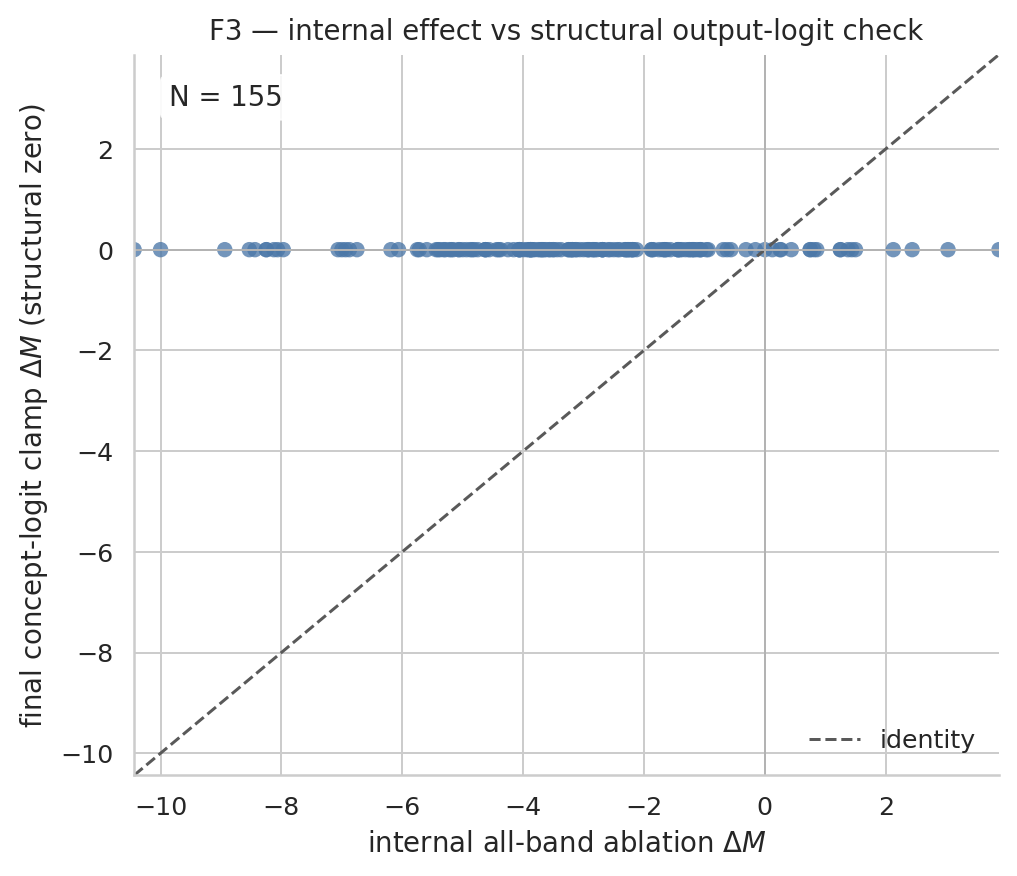

random_null /home/jovyan/j-space-thoughts/results/figures/controls_random_direction_null.png


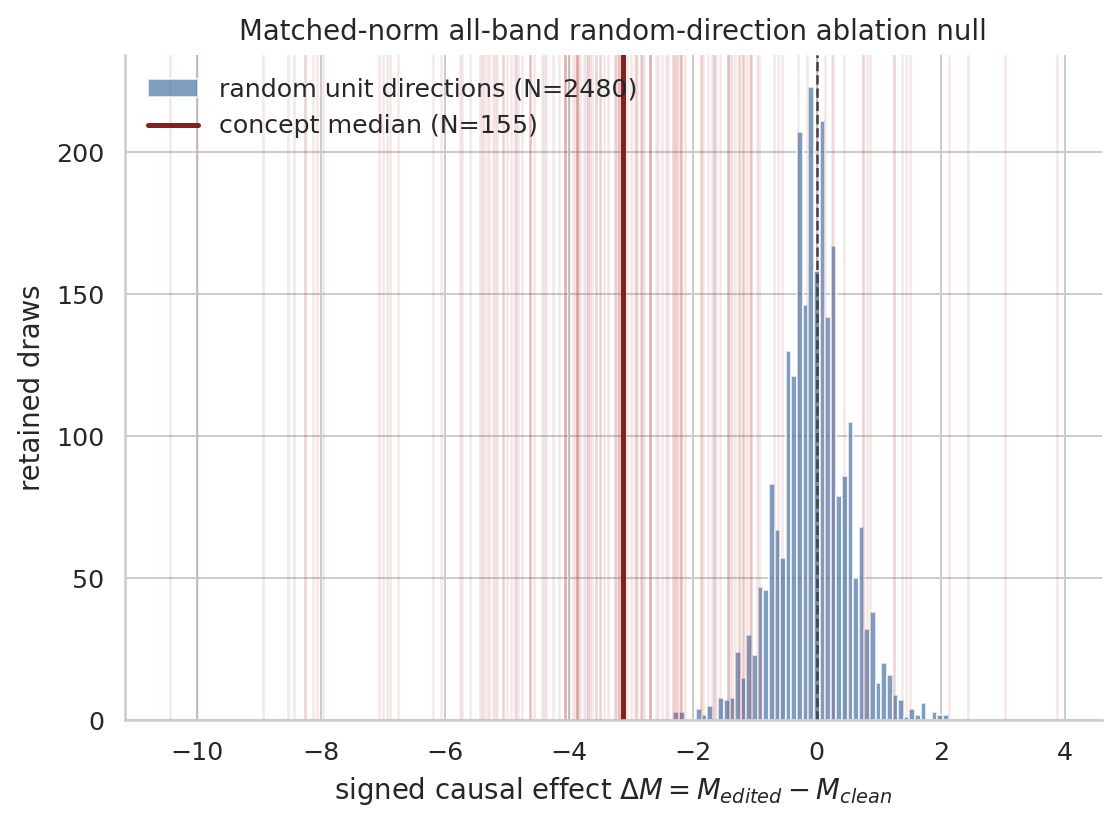

capability /home/jovyan/j-space-thoughts/results/figures/controls_capability.png


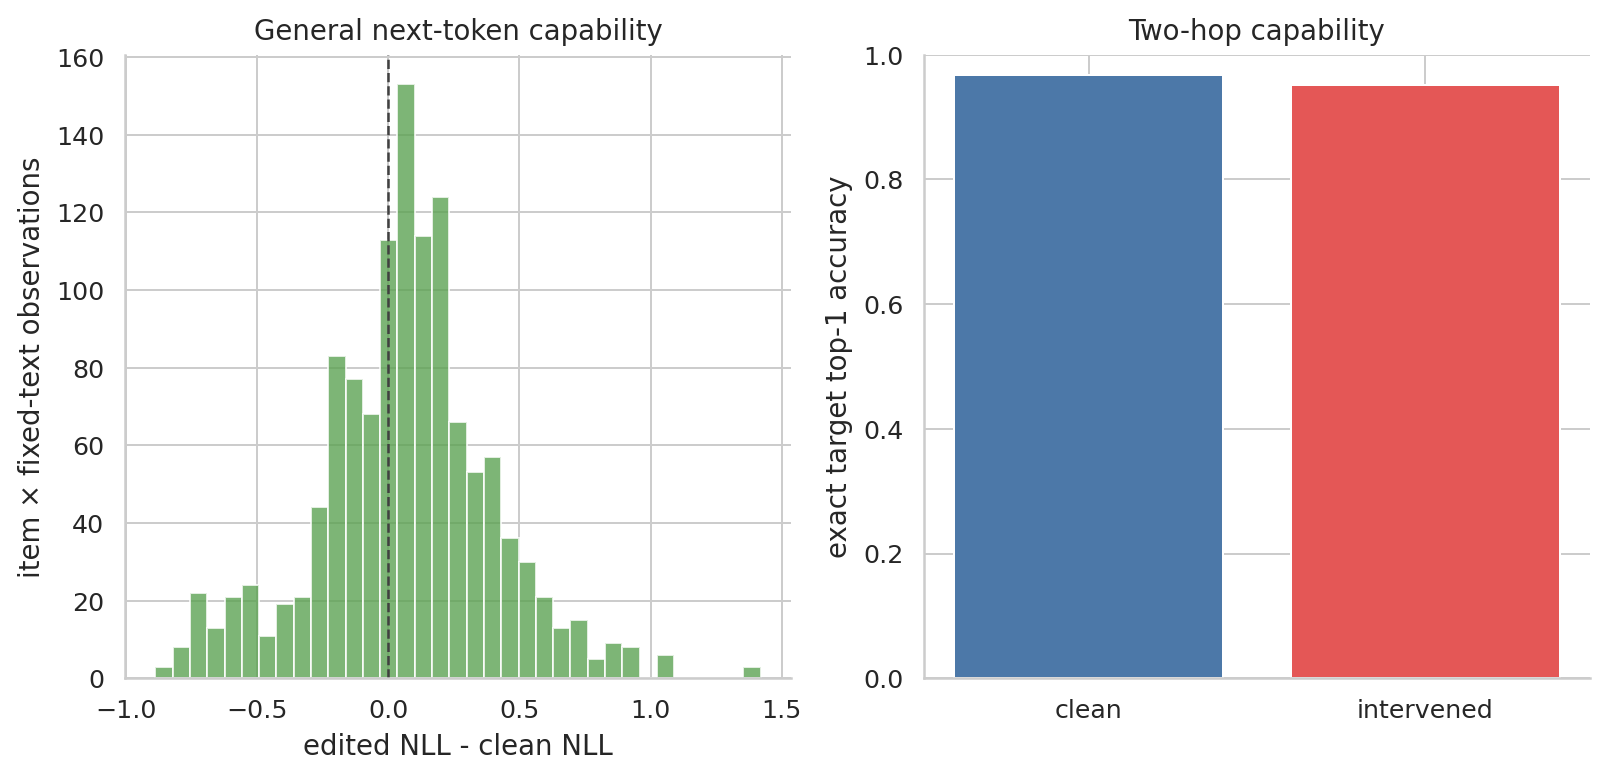

known_narration /home/jovyan/j-space-thoughts/results/figures/controls_known_narration.png


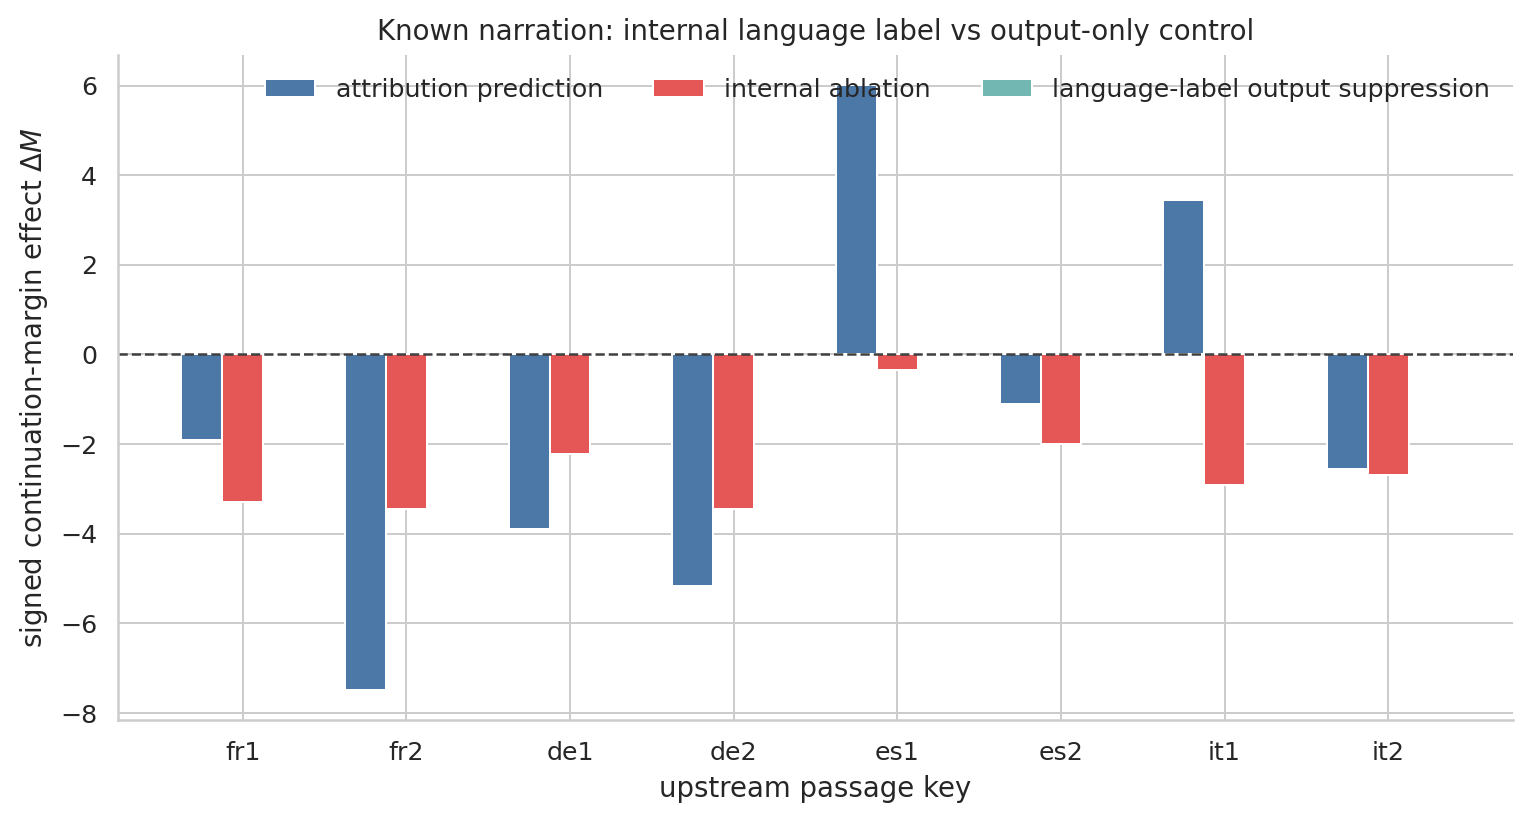

In [6]:
from IPython.display import Image, display

for name, path in controls['figures'].items():
    print(name, path)
    display(Image(filename=path))

In [7]:
print('PHASE 03 COMPUTED')
print('FINAL CONCEPT-LOGIT STRUCTURAL ZERO', controls['core_output_suppression_assertion']['structural_zero_assertion'])
print('ABSENT-COORDINATE NULL FEASIBILITY', controls['absent_coordinate_null']['rank_feasibility'])
print('ABSENT-COORDINATE NULL', controls['absent_coordinate_null']['aggregate'])
print('CONCEPT-TO-ABSENT STRESS TEST (NOT A NULL)', controls['concept_to_absent_stress_test']['aggregate'])
print('KNOWN-NARRATION', controls['known_narration']['status'])
if controls['known_narration']['status'] != 'PASS':
    print('The preregistered narration positive control did not reproduce; narration-class claims are not licensed at this scale.')

PHASE 03 COMPUTED
FINAL CONCEPT-LOGIT STRUCTURAL ZERO {'status': 'PASS', 'classification': 'structural-zero instrumentation/direct-logit-steering check; not additional causal evidence', 'operation': 'clamp only the final concept-token vocabulary logit', 'behavior_metric': 'target-token logit minus foil-token logit', 'structural_reason': 'concept token IDs are disjoint from both metric token IDs, so the clamped logit is not an operand of the metric', 'n_rows': 155, 'all_token_ids_disjoint': True, 'all_deltas_exact_zero': True, 'rows': [{'name': 'animal-legs-buffalo2', 'concept_token_id': 81355, 'target_token_id': 3040, 'foil_token_id': 8063, 'concept_disjoint_from_target_and_foil': True, 'output_suppression_delta': 0.0, 'exact_zero': True}, {'name': 'animal-nose-elephant', 'concept_token_id': 45740, 'target_token_id': 37311, 'foil_token_id': 24459, 'concept_disjoint_from_target_and_foil': True, 'output_suppression_delta': 0.0, 'exact_zero': True}, {'name': 'basketball-players', 'concept